Usando o dataset seeds.csv, encontre o melhor número de clusters para o K-means usando *inertia* e *silhouette coefficient*

In [1]:
import pandas as pd

df = pd.read_csv('seeds.csv')
y_true = df["grain_variety"]
df.head()

/Users/dhenyfernandes/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


,area,perimeter,compactness,length,width,asymmetry_coefficient,groove_length,grain_variety
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,Kama wheat
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,Kama wheat
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,Kama wheat
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,Kama wheat
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,Kama wheat


In [2]:
X = df.drop(columns=["grain_variety"])

In [3]:
X

,area,perimeter,compactness,length,width,asymmetry_coefficient,groove_length
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175
...,...,...,...,...,...,...,...
205,12.19,13.20,0.8783,5.137,2.981,3.631,4.870
206,11.23,12.88,0.8511,5.140,2.795,4.325,5.003
207,13.20,13.66,0.8883,5.236,3.232,8.315,5.056
208,11.84,13.21,0.8521,5.175,2.836,3.598,5.044


In [4]:
y_true

0          Kama wheat
1          Kama wheat
2          Kama wheat
3          Kama wheat
4          Kama wheat
            ...      
205    Canadian wheat
206    Canadian wheat
207    Canadian wheat
208    Canadian wheat
209    Canadian wheat
Name: grain_variety, Length: 210, dtype: object

### TO-DO

* normalize os dados de treino
* Crie uma instância do K-means chamada *model* com k clusters (k variando de 1 a 6)
* Treine um modelo usando os dados (X) para cada k
* adicione o valor de *inertias_* de cada modelo numa lista chamada inertias

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [6]:
# resposta
from sklearn.cluster import KMeans

ks = range(1, 7)
inertias = []

for k in ks:
    
    model = KMeans(n_clusters=k)

   
    model.fit(X)

    
    inertias.append(model.inertia_)

### TO-DO
* plote as inércias para determinar o melhor valor de k

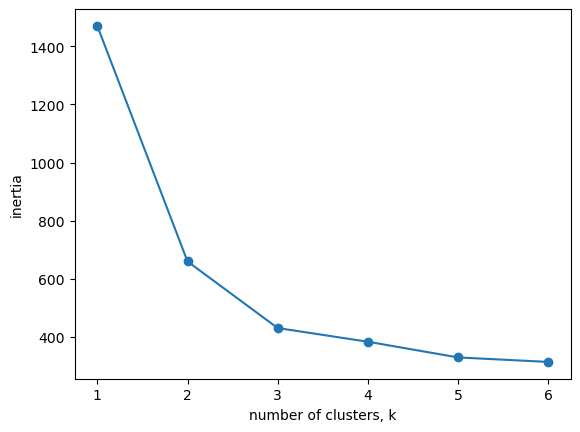

In [7]:
# resposta
import matplotlib.pyplot as plt

plt.plot(ks, inertias, '-o')
plt.xlabel('number of clusters, k')
plt.ylabel('inertia')
plt.xticks(ks)
plt.show()

### TO-DO
* Encontre o melhor valor de k usando *silhouette coefficient* 


In [8]:
# resposta
from sklearn.metrics import silhouette_score
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X)
                for k in range(1, 7)]

In [9]:
silhouette_scores = [silhouette_score(X, model.labels_)
                     for model in kmeans_per_k[1:]]

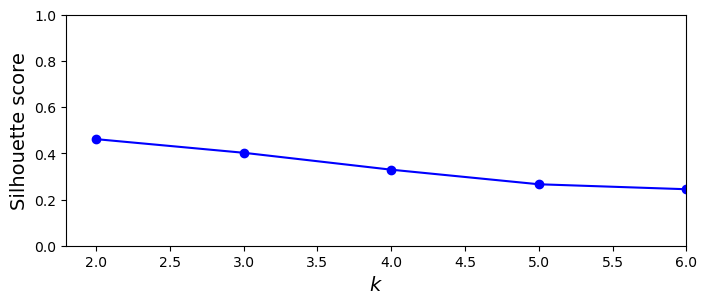

In [10]:
plt.figure(figsize=(8, 3))
plt.plot(range(2, 7), silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.axis([1.8, 6, 0., 1])
plt.show()

### TO-DO
* Treine um cluster hierárquico e veja como essa solução se compara com a do k-means
* use o método fit_predict tanto do k-means quanto do cluster hierárquico para comparar os resultados
* Use a variável y_true e o método Crosstab para analisar os resultados

In [11]:
# resposta hclus
from sklearn.cluster import AgglomerativeClustering

cluster = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
cluster.fit_predict(X)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 0, 0, 1, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 0, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2])

In [12]:
# resposta kmeans
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit_predict(X)

array([2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 2, 2, 2, 2, 2,
       2, 2, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 2, 0, 2, 2, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int32)

In [13]:
clusters = kmeans.fit_predict(X)

df["cluster"] = clusters
pd.crosstab(
    df["cluster"],
    df["grain_variety"],
    margins=True
)

grain_variety,Canadian wheat,Kama wheat,Rosa wheat,All
cluster,,,,
0,0,2,66,68
1,65,4,0,69
2,5,64,4,73
All,70,70,70,210


In [14]:
hclusters = cluster.fit_predict(X)

df["hcluster"] = hclusters
pd.crosstab(
    df["hcluster"],
    df["grain_variety"],
    margins=True
)

grain_variety,Canadian wheat,Kama wheat,Rosa wheat,All
hcluster,,,,
0,5,64,4,73
1,0,4,66,70
2,65,2,0,67
All,70,70,70,210


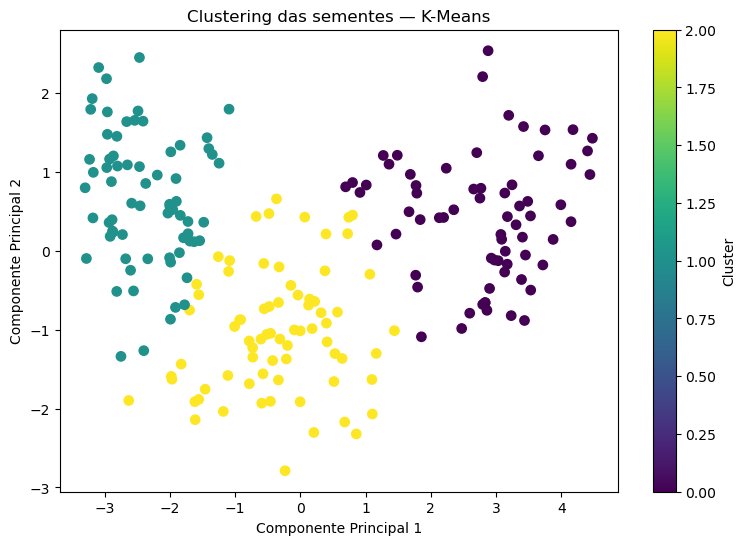

In [15]:
#visualizacao
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(9, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    cmap="viridis",
    s=45
)

plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("Clustering das sementes — K-Means")
plt.colorbar(label="Cluster")
plt.show()